# benchmark visual por janela

Notebook para comparar o **F1-Score** dos modelos, temporada a temporada

- Fonte dos dados: `results/experimento_03_detalhado` (predicoes detalhadas de cada modelo, jogo a jogo)
- Uma figura para cada janela: `5`, `10` e `15`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
from IPython.display import display
from sklearn.metrics import f1_score


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'results' / 'experimento_03_detalhado').exists():
            return candidate
    raise FileNotFoundError(
        'Nao foi possivel localizar a raiz do projeto com a pasta results/experimento_03_detalhado.'
    )


BASE_DIR = find_project_root(Path.cwd())
PASTA_DETALHADO = BASE_DIR / 'results' / 'experimento_03_detalhado'
JANELAS = [5, 10, 15]

MODELOS = {
    'SVM':                 'svm_experimento_03_predicoes_detalhadas.csv',
    'KNN':                 'knn_experimento_03_predicoes_detalhadas.csv',
    'Extra Trees':         'extra_trees_experimento_03_predicoes_detalhadas.csv',
    'Regressao Logistica': 'regressao_logistica_experimento_03_predicoes_detalhadas.csv',
    'LightGBM':            'lightgbm_experimento_03_predicoes_detalhadas.csv',
}

# mesmas cores/marcadores usados no plot_comparativo do stack_ensemble.ipynb
CORES = {
    'SVM':                 '#1f77b4',
    'KNN':                 '#ff7f0e',
    'Extra Trees':         '#2ca02c',
    'Regressao Logistica': '#d62728',
    'LightGBM':            '#9467bd',
}

MARCADORES = {
    'SVM':                 'o',
    'KNN':                 's',
    'Extra Trees':         '^',
    'Regressao Logistica': 'D',
    'LightGBM':            'P',
}

print(f'BASE_DIR: {BASE_DIR}')
print(f'PASTA_DETALHADO: {PASTA_DETALHADO}')

BASE_DIR: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction
PASTA_DETALHADO: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_03_detalhado


## Carregar resultados de uma janela

Para cada modelo, li o CSV detalhado, filtrei pela janela pedida e calculei F1-Score por temporada.


In [2]:
def load_window_results(janela):
    f1_por_modelo = {}
    jogos_por_temporada = None

    for nome_modelo, arquivo in MODELOS.items():
        df = pd.read_csv(PASTA_DETALHADO / arquivo)
        df = df[df['Janela Incremental'] == janela]

        f1_temporada = (
            df.groupby('Temporada')
            .apply(lambda g: f1_score(
                g['Resultado Real'].astype(int),
                g['Previsao'].astype(int),
                average='weighted',
                zero_division=0
            ))
        )
        f1_por_modelo[nome_modelo] = f1_temporada

        contagem = df.groupby('Temporada').size()
        jogos_por_temporada = contagem if jogos_por_temporada is None else jogos_por_temporada

    temporadas_order = sorted(jogos_por_temporada.index)

    f1_df = pd.DataFrame(
        {m: s.reindex(temporadas_order) for m, s in f1_por_modelo.items()},
        index=temporadas_order
    )
    jogos = jogos_por_temporada.reindex(temporadas_order)

    return f1_df, jogos, temporadas_order


## Grafico da janela

In [3]:
def plot_janela(janela):
    f1_df, jogos, temporadas_order = load_window_results(janela)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(16, 9),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True
    )

    # --- Plotar cada modelo ---
    for nome_modelo in MODELOS.keys():
        serie = f1_df[nome_modelo]

        ax1.plot(
            f1_df.index,
            serie,
            marker=MARCADORES[nome_modelo],
            color=CORES[nome_modelo],
            linewidth=1.5,
            markersize=6,
            label=nome_modelo,
            alpha=0.65
        )

    # --- Rotulo do melhor modelo em cada temporada ---
    for i, temporada in enumerate(f1_df.index):
        valores_temporada = f1_df.loc[temporada]

        melhor_modelo = valores_temporada.idxmax()
        melhor_valor = valores_temporada.max()

        ax1.annotate(
            f"{melhor_valor:.2f}",
            xy=(i, melhor_valor),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=CORES[melhor_modelo],
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            )
        )

    # --- Linha de referencia: media geral calculada para esta janela ---
    media_geral = float(f1_df.values.mean())

    ax1.axhline(
        media_geral,
        color="#444444",
        linestyle="--",
        linewidth=1.3,
        alpha=0.8,
        label=f"Media Geral ({media_geral:.2f})"
    )

    ax1.text(
        x=len(temporadas_order) - 0.5,
        y=media_geral + 0.006,
        s=f"Media: {media_geral:.2f}",
        color="#333333",
        fontsize=9,
        fontweight="bold",
        ha="right",
        va="bottom",
        bbox=dict(
            boxstyle="square,pad=0.2",
            facecolor="white",
            edgecolor="#cccccc",
            alpha=0.85
        )
    )

    ax1.set_ylabel("F1-Score (weighted)", fontsize=12)
    ax1.set_ylim(0.40, 0.80)
    ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
    ax1.legend(loc="upper right", fontsize=9, ncol=2)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    ax1.tick_params(axis="x", rotation=45)

    # --- Grafico de barras: total de jogos por temporada ---
    ax2.bar(
        temporadas_order,
        jogos.values,
        color="#1f77b4",
        alpha=0.4,
        edgecolor="#1f77b4"
    )

    for i, v in enumerate(jogos.values):
        ax2.text(
            i,
            v + 5,
            str(v),
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax2.set_ylabel("Jogos", fontsize=10)
    ax2.set_ylim(0, max(jogos.values) * 1.25)
    ax2.grid(axis="y", linestyle="--", alpha=0.3)
    ax2.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    display(f1_df.style.format("{:.4f}"))

    return f1_df, jogos


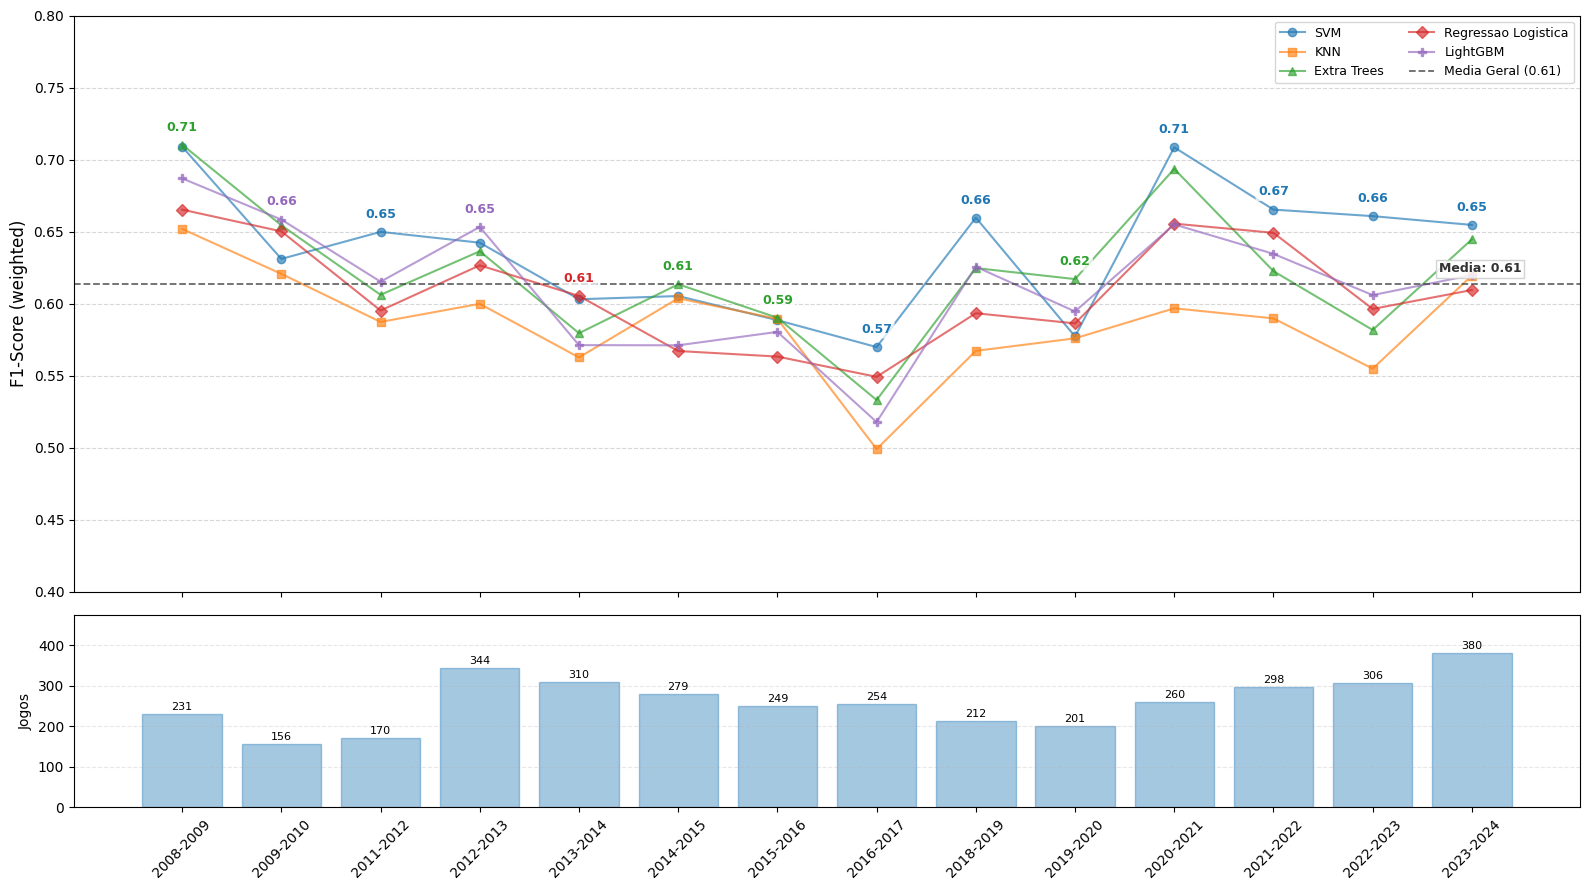

,SVM,KNN,Extra Trees,Regressao Logistica,LightGBM
2008-2009,0.7089,0.6518,0.7103,0.6652,0.6869
2009-2010,0.6310,0.6206,0.6543,0.6501,0.6583
2011-2012,0.6498,0.5872,0.6060,0.5951,0.6152
2012-2013,0.6422,0.5998,0.6363,0.6265,0.6532
2013-2014,0.6030,0.5626,0.5794,0.6053,0.5711
2014-2015,0.6052,0.6036,0.6134,0.5670,0.5710
2015-2016,0.5885,0.5893,0.5901,0.5632,0.5803
2016-2017,0.5698,0.4989,0.5330,0.5491,0.5177
2018-2019,0.6596,0.5671,0.6246,0.5933,0.6256
2019-2020,0.5772,0.5758,0.6170,0.5862,0.5945


(                SVM       KNN  Extra Trees  Regressao Logistica  LightGBM
 2008-2009  0.708899  0.651818     0.710311             0.665203  0.686893
 2009-2010  0.630984  0.620585     0.654313             0.650114  0.658304
 2011-2012  0.649775  0.587235     0.606047             0.595148  0.615161
 2012-2013  0.642246  0.599800     0.636305             0.626513  0.653213
 2013-2014  0.602969  0.562585     0.579387             0.605274  0.571104
 2014-2015  0.605190  0.603629     0.613367             0.567024  0.570993
 2015-2016  0.588458  0.589326     0.590118             0.563181  0.580308
 2016-2017  0.569768  0.498942     0.532997             0.549101  0.517716
 2018-2019  0.659648  0.567136     0.624617             0.593270  0.625572
 2019-2020  0.577156  0.575832     0.616972             0.586203  0.594485
 2020-2021  0.708462  0.596697     0.693488             0.655470  0.654925
 2021-2022  0.665227  0.589686     0.622494             0.649100  0.634500
 2022-2023  0.660682  0.5

In [4]:
plot_janela(5)

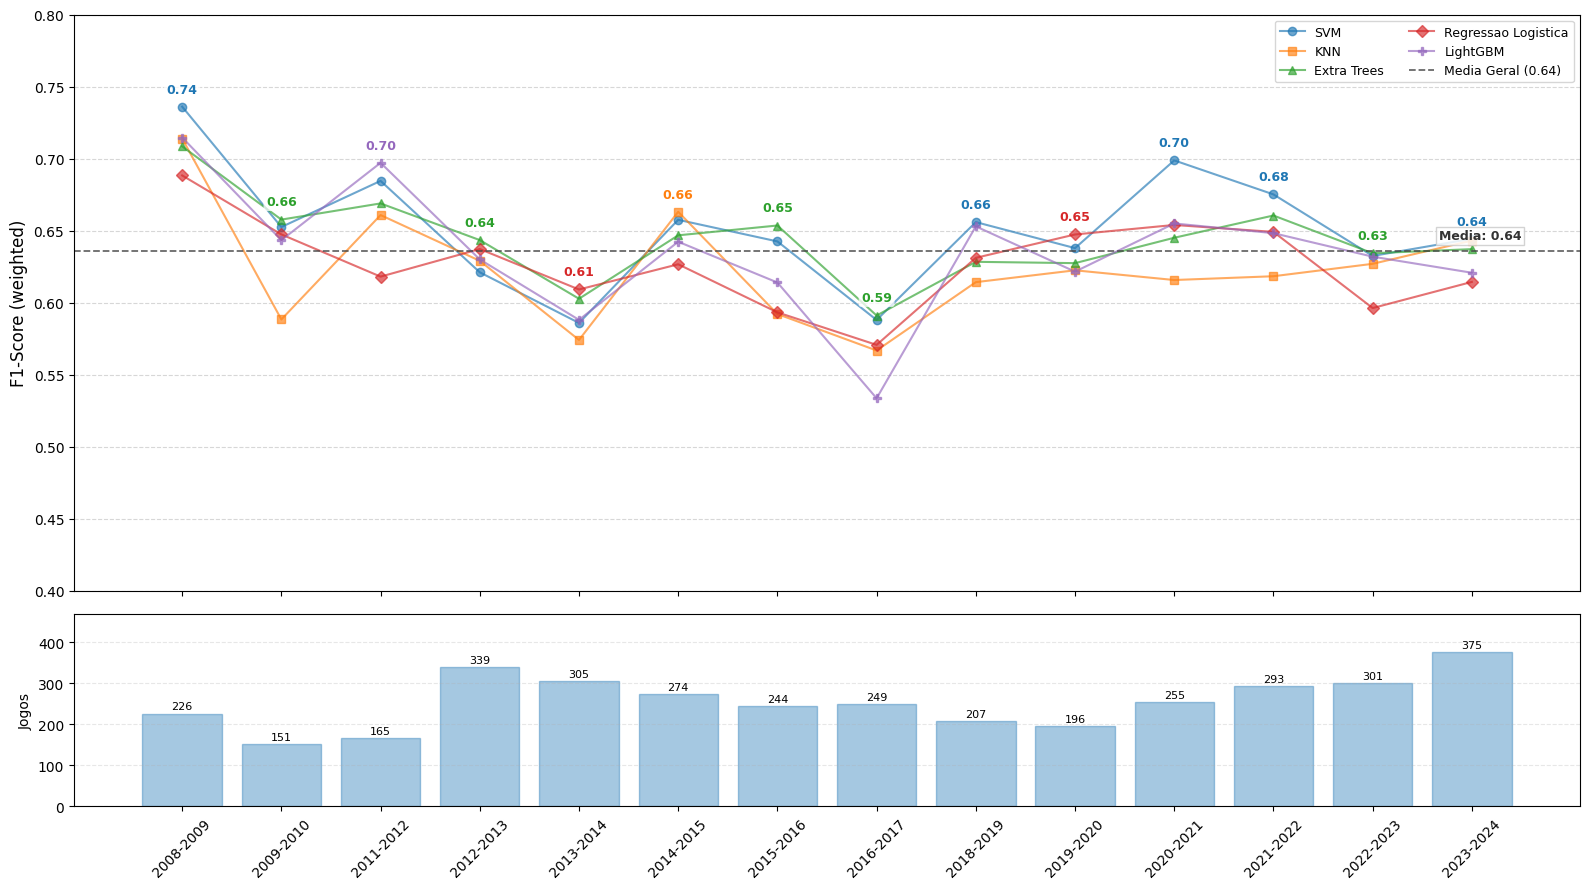

,SVM,KNN,Extra Trees,Regressao Logistica,LightGBM
2008-2009,0.7360,0.7139,0.7084,0.6883,0.7146
2009-2010,0.6524,0.5883,0.6576,0.6473,0.6433
2011-2012,0.6845,0.6607,0.6688,0.6180,0.6970
2012-2013,0.6210,0.6290,0.6434,0.6371,0.6299
2013-2014,0.5858,0.5740,0.6026,0.6091,0.5880
2014-2015,0.6574,0.6630,0.6467,0.6266,0.6422
2015-2016,0.6424,0.5920,0.6535,0.5932,0.6139
2016-2017,0.5879,0.5667,0.5910,0.5706,0.5335
2018-2019,0.6558,0.6142,0.6283,0.6310,0.6529
2019-2020,0.6378,0.6224,0.6273,0.6473,0.6214


(                SVM       KNN  Extra Trees  Regressao Logistica  LightGBM
 2008-2009  0.736010  0.713871     0.708418             0.688255  0.714592
 2009-2010  0.652434  0.588254     0.657579             0.647302  0.643299
 2011-2012  0.684468  0.660741     0.668824             0.617981  0.697020
 2012-2013  0.620991  0.628953     0.643353             0.637141  0.629934
 2013-2014  0.585825  0.574026     0.602627             0.609058  0.587957
 2014-2015  0.657447  0.662995     0.646666             0.626560  0.642218
 2015-2016  0.642436  0.592012     0.653486             0.593173  0.613911
 2016-2017  0.587873  0.566686     0.590978             0.570591  0.533496
 2018-2019  0.655843  0.614153     0.628265             0.631039  0.652867
 2019-2020  0.637783  0.622377     0.627347             0.647251  0.621446
 2020-2021  0.698697  0.615628     0.644977             0.653863  0.654902
 2021-2022  0.675084  0.618259     0.660426             0.649046  0.648170
 2022-2023  0.632336  0.6

In [5]:
plot_janela(10)

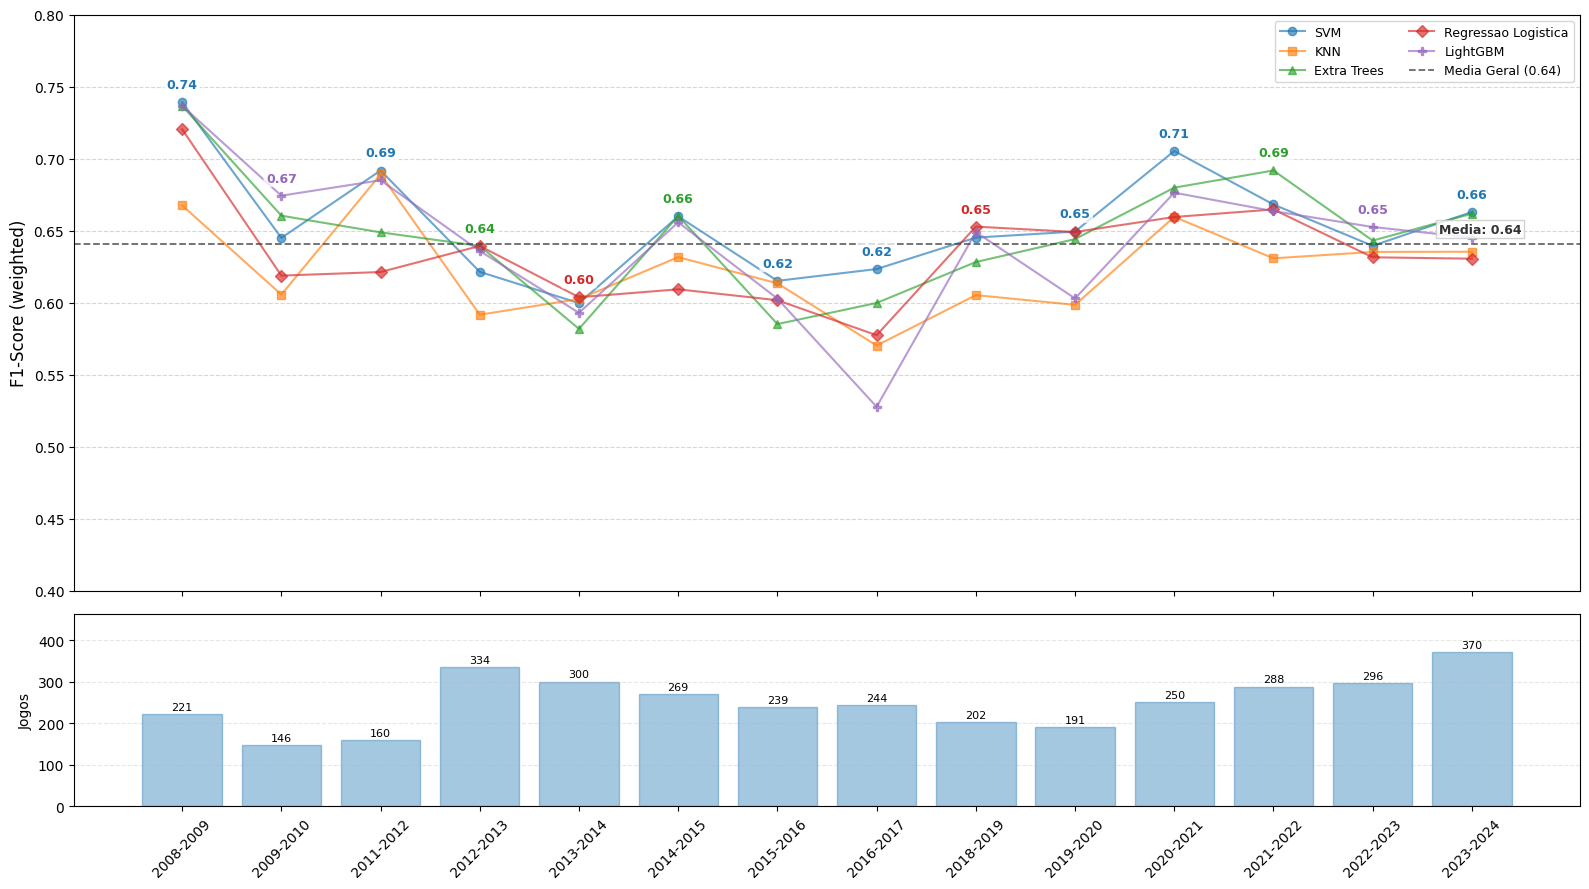

,SVM,KNN,Extra Trees,Regressao Logistica,LightGBM
2008-2009,0.7391,0.6674,0.7366,0.7203,0.7366
2009-2010,0.6449,0.6055,0.6603,0.6187,0.6742
2011-2012,0.6917,0.6890,0.6487,0.6212,0.6849
2012-2013,0.6213,0.5916,0.6393,0.6393,0.6358
2013-2014,0.5996,0.6024,0.5817,0.6037,0.5928
2014-2015,0.6598,0.6315,0.6602,0.6092,0.6557
2015-2016,0.6151,0.6133,0.5850,0.6016,0.6027
2016-2017,0.6232,0.5701,0.5997,0.5773,0.5276
2018-2019,0.6451,0.6051,0.6281,0.6527,0.6489
2019-2020,0.6493,0.5984,0.6440,0.6490,0.6028


(                SVM       KNN  Extra Trees  Regressao Logistica  LightGBM
 2008-2009  0.739088  0.667423     0.736580             0.720290  0.736580
 2009-2010  0.644869  0.605502     0.660309             0.618683  0.674198
 2011-2012  0.691660  0.689004     0.648731             0.621181  0.684923
 2012-2013  0.621303  0.591552     0.639290             0.639290  0.635765
 2013-2014  0.599571  0.602432     0.581701             0.603672  0.592842
 2014-2015  0.659820  0.631517     0.660157             0.609168  0.655743
 2015-2016  0.615063  0.613322     0.585045             0.601595  0.602737
 2016-2017  0.623244  0.570142     0.599693             0.577316  0.527588
 2018-2019  0.645083  0.605143     0.628106             0.652713  0.648923
 2019-2020  0.649272  0.598385     0.644038             0.648983  0.602834
 2020-2021  0.705214  0.659486     0.679759             0.659393  0.676280
 2021-2022  0.668077  0.630689     0.691678             0.664639  0.663473
 2022-2023  0.639368  0.6

In [6]:
plot_janela(15)